In [1]:
import pandas as pd

In [6]:
df = pd.read_csv("spam.csv",encoding="latin-1")

In [7]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis = 1,inplace=True)

In [9]:
df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
a = df[df["v1"] == "ham"]
b = df[df["v1"] == "spam"]

In [12]:
new_a = a.sample()

In [13]:
len(df)

5572

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
encoder = LabelEncoder()

In [16]:
df["v1"] = encoder.fit_transform(df["v1"])

In [17]:
df["v1"].value_counts()

v1
0    4825
1     747
Name: count, dtype: int64

In [18]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


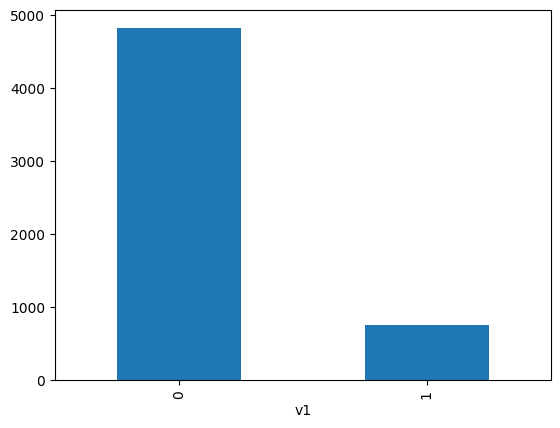

In [19]:
import matplotlib.pyplot as plt

df["v1"].value_counts().plot(kind="bar")
plt.show()

In [20]:
import matplotlib.pyplot as plt

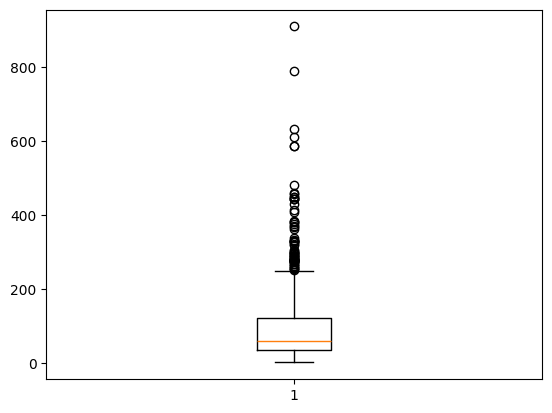

In [21]:
df["length"] = df["v2"].apply(len)
plt.boxplot(df["length"])
plt.show()

In [22]:
df.isnull().sum()

v1        0
v2        0
length    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(403)

In [24]:
df = df.drop_duplicates(keep = 'first')

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.head()

,v1,v2,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
def count_words(text):
    words = text.split()
    return len(words)

def count_sentense(text):
    sentence = text.split(".")
    return len(sentence)

In [28]:
df["num_word"] = df["v2"].apply(count_words)
df["sentence"] = df["v2"].apply(count_sentense)

In [29]:
df.head()

,v1,v2,length,num_word,sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,20,9
1,0,Ok lar... Joking wif u oni...,29,6,7
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,7
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


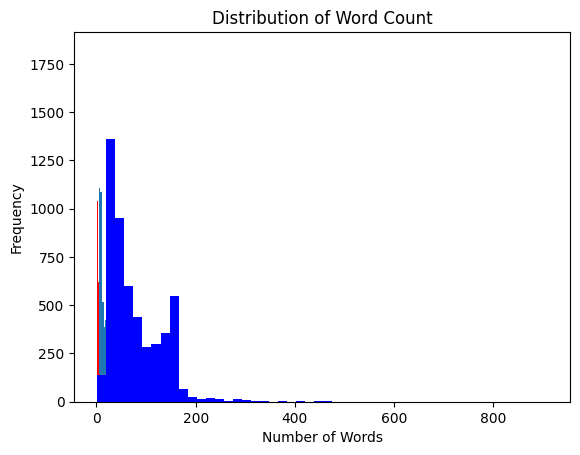

In [30]:
import matplotlib.pyplot as plt

plt.hist(df["num_word"], bins=50)
plt.hist(df["sentence"], bins=50,color='r')
plt.hist(df["length"], bins=50,color = 'b')

plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [31]:
df['v2'] = df['v2'].str.lower()
df['v2'] = df['v2'].str.replace(" ","")

In [32]:
df.head()

,v1,v2,length,num_word,sentence
0,0,"gountiljurongpoint,crazy..availableonlyinbugis...",111,20,9
1,0,oklar...jokingwifuoni...,29,6,7
2,1,freeentryin2awklycomptowinfacupfinaltkts21stma...,155,28,2
3,0,udunsaysoearlyhor...ucalreadythensay...,49,11,7
4,0,"nahidon'tthinkhegoestousf,helivesaroundherethough",61,13,1


In [33]:
df["v2"] = df["v2"].str.replace(r"[^a-zA-Z0-9 ]", "", regex=True)

In [34]:
df.head()

,v1,v2,length,num_word,sentence
0,0,gountiljurongpointcrazyavailableonlyinbugisngr...,111,20,9
1,0,oklarjokingwifuoni,29,6,7
2,1,freeentryin2awklycomptowinfacupfinaltkts21stma...,155,28,2
3,0,udunsaysoearlyhorucalreadythensay,49,11,7
4,0,nahidontthinkhegoestousfhelivesaroundherethough,61,13,1


In [35]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [36]:
import nltk
from nltk.corpus import stopwords

In [37]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
stop_words = stopwords.words("english")

In [39]:
def remove_stopwords(text):
    words = text.split()
    new_words = []

    for word in words:
        if word not in stop_words:
            new_words.append(word)

    return " ".join(new_words)

In [40]:
df["v2"] = df["v2"].apply(remove_stopwords)

In [41]:
df.head()

,v1,v2,length,num_word,sentence
0,0,gountiljurongpointcrazyavailableonlyinbugisngr...,111,20,9
1,0,oklarjokingwifuoni,29,6,7
2,1,freeentryin2awklycomptowinfacupfinaltkts21stma...,155,28,2
3,0,udunsaysoearlyhorucalreadythensay,49,11,7
4,0,nahidontthinkhegoestousfhelivesaroundherethough,61,13,1


In [42]:
from nltk.stem import PorterStemmer

In [43]:
ps = PorterStemmer()

In [44]:
def remove_stopwords(text):
    words = text.split()
    new_words = []

    for word in words:
        if word not in stop_words:
            new_words.append(word)

    return " ".join(new_words)

In [45]:
df["v2"] = df["v2"].apply(remove_stopwords)

In [46]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [47]:
x = tfidf.fit_transform(df["v2"]).toarray()

In [48]:
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [49]:
y = df['v1'].values

In [50]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x_train, x_test,y_train,y_test = train_test_split(x,y,random_state = 42,test_size = 0.2)

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    random_state=42
)

In [55]:
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_pred = model.predict(x_test)

In [57]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [58]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [59]:
acc = accuracy_score(y_test,y_pred)
con = confusion_matrix(y_test,y_pred)

In [60]:
acc

0.8665377176015474

In [61]:
con

array([[889,   0],
       [138,   7]])

In [62]:
def predict_spam(message):
    message = message.lower()
    message = tfidf.transform([message])
    result = model.predict(message)
    
    if result[0] == 1:
        return "Spam"
    else:
        return "Not Spam"

In [63]:
predict_spam("Subject: 🎉 Congratulations! You Won a $1000 Gift Card!")

'Not Spam'

In [64]:
from sklearn.naive_bayes import MultinomialNB

In [65]:
mod = MultinomialNB()

In [66]:
mod.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [67]:
def new_predict_spam(message):
    message = message.lower()
    message = tfidf.transform([message])

    result = mod.predict_proba(message)

    spam_prob = result[0][1]

    if spam_prob >= 0.5:
        print(f"Spam Mail  | probability: {spam_prob}")
    else:
        print(f"Not Spam Mail | probability: {spam_prob}")

In [68]:
new_predict_spam("Subject: 🎉 Congratulations! You Won a $1000 Gift Card!")

Not Spam Mail | probability: 0.12285368802902062


In [69]:
new_y_pred = mod.predict(x_test)

In [70]:
con = confusion_matrix(y_test,y_pred)

In [71]:
con

array([[889,   0],
       [138,   7]])

In [72]:
from sklearn.linear_model import LogisticRegression

In [73]:
logr = LogisticRegression()

In [74]:
logr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [75]:
p_log = logr.predict(x_test)

In [76]:
con = confusion_matrix(y_test,p_log)

In [77]:
con

array([[889,   0],
       [145,   0]])

In [79]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [82]:
from xgboost import XGBClassifier

In [83]:
xg_model = XGBClassifier(
    n_enstimators = 200,
    learning_rate = 0.1,
    max_depth = 6
)

In [84]:
xg_model.fit(x_train,y_train)

C:\Users\shubh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:04:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_enstimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [86]:
xg_pred = xg_model.predict(x_test)

In [87]:
xg_pred

array([0, 0, 0, ..., 0, 0, 0])

In [89]:
confusion_matrix(y_test,xg_pred)

array([[889,   0],
       [145,   0]])

In [92]:
accuracy_score(y_test,xg_pred)

0.8597678916827853

In [100]:
def xg_predict_spam(message):

    message = message.lower()

    message = tfidf.transform([message])

    result = xg_model.predict_proba(message)

    spam_prob = result[0][1]

    if spam_prob >= 0.5:
        print(f"Spam Mail | probability: {spam_prob}")

    else:
        print(f"Not Spam Mail | probability: {spam_prob}")

In [101]:
xg_predict_spam("Subject: 🎉 Congratulations! You Won a $1000 Gift Card!")

Not Spam Mail | probability: 0.12285370379686356
